# Criterios de parada en Algoritmos Genéticos
## Problema de la Mochila (0/1)

En este notebook se resuelve el problema de la mochila mediante un algoritmo genético completo.
Una vez resuelto, se analizan **distintos criterios de parada**, manteniendo fijo el resto del diseño.

## 1. Definición del problema

El problema de la mochila consiste en seleccionar objetos para maximizar el valor total
sin superar una capacidad máxima.

Es un problema combinatorio clásico, ideal para algoritmos genéticos.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt


In [2]:
# Definición del problema
NUM_ITEMS = 25
CAPACIDAD = 50
pesos = np.random.randint(1, 15, size=NUM_ITEMS)
valores = np.random.randint(5, 30, size=NUM_ITEMS)


## 2. Representación y fitness

Cada individuo es un vector binario.
El fitness penaliza las soluciones que superan la capacidad.

In [3]:
def fitness(ind):
    peso = np.sum(ind * pesos)
    valor = np.sum(ind * valores)
    if peso > CAPACIDAD:
        return 0
    return valor


## 3. Algoritmo genético base

Se implementa un GA estándar con:
- selección por torneo
- cruce uniforme
- mutación bit-flip
- reemplazo generacional completo

Este diseño se mantiene fijo durante toda la sesión.

In [4]:
def poblacion_inicial(P, L):
    return [np.random.randint(0,2,size=L) for _ in range(P)]


In [5]:
def seleccion_torneo(pobl, k=3):
    sel = random.sample(pobl, k)
    sel.sort(key=lambda x: fitness(x), reverse=True)
    return sel[0]


In [6]:
def cruce_uniforme(p1,p2):
    return np.array([p1[i] if random.random()<0.5 else p2[i] for i in range(len(p1))])


In [7]:
def mutacion(ind, p=0.05):
    ind = ind.copy()
    for i in range(len(ind)):
        if random.random()<p:
            ind[i] = 1-ind[i]
    return ind


## 4. Entropía genética

Se utiliza la entropía genética para medir la diversidad de la población.

In [8]:
def entropia_genetica(pobl):
    pobl = np.array(pobl)
    H = 0
    for j in range(pobl.shape[1]):
        p = np.mean(pobl[:,j])
        if 0 < p < 1:
            H += -(p*np.log2(p)+(1-p)*np.log2(1-p))
    return H/pobl.shape[1]


## 5. Ejecución del GA con distintos criterios de parada

Se implementan **distintas funciones de parada**, manteniendo fijo el resto del algoritmo.

In [9]:
def ejecutar_ga(max_gen=500, sin_mejora=None, entropia_min=None):
    P = 100
    pobl = poblacion_inicial(P, NUM_ITEMS)
    mejor_global = None
    est = 0
    hist_fit = []
    hist_ent = []
    for g in range(max_gen):
        nueva = []
        for _ in range(P):
            p1 = seleccion_torneo(pobl)
            p2 = seleccion_torneo(pobl)
            h = mutacion(cruce_uniforme(p1,p2))
            nueva.append(h)
        pobl = nueva
        mejor = max(pobl, key=lambda x: fitness(x))
        fit = fitness(mejor)
        
        # print(f"El mejor individuo de la generación {g} es {mejor} con valor {str(fit)}")

        hist_fit.append(fit)
        ent = entropia_genetica(pobl)
        hist_ent.append(ent)
        if mejor_global is None or fit > fitness(mejor_global):
            mejor_global = mejor
            est = 0
        else:
            est += 1
        if sin_mejora and est >= sin_mejora:
            break
        if entropia_min and ent <= entropia_min:
            break
    print(f"El mejor global es {mejor_global} con valor {str(fitness(mejor_global))}")
    return hist_fit, hist_ent


## 6. Comparación de estrategias de parada

Se comparan los siguientes criterios:
- máximo de generaciones
- falta de mejora
- entropía genética

In [10]:
res_gen = ejecutar_ga(max_gen=300)
res_est = ejecutar_ga(max_gen=300, sin_mejora=40)
res_ent = ejecutar_ga(max_gen=300, entropia_min=0.05)


El mejor global es [0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1] con valor 197
El mejor global es [0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1] con valor 196
El mejor global es [0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1] con valor 197


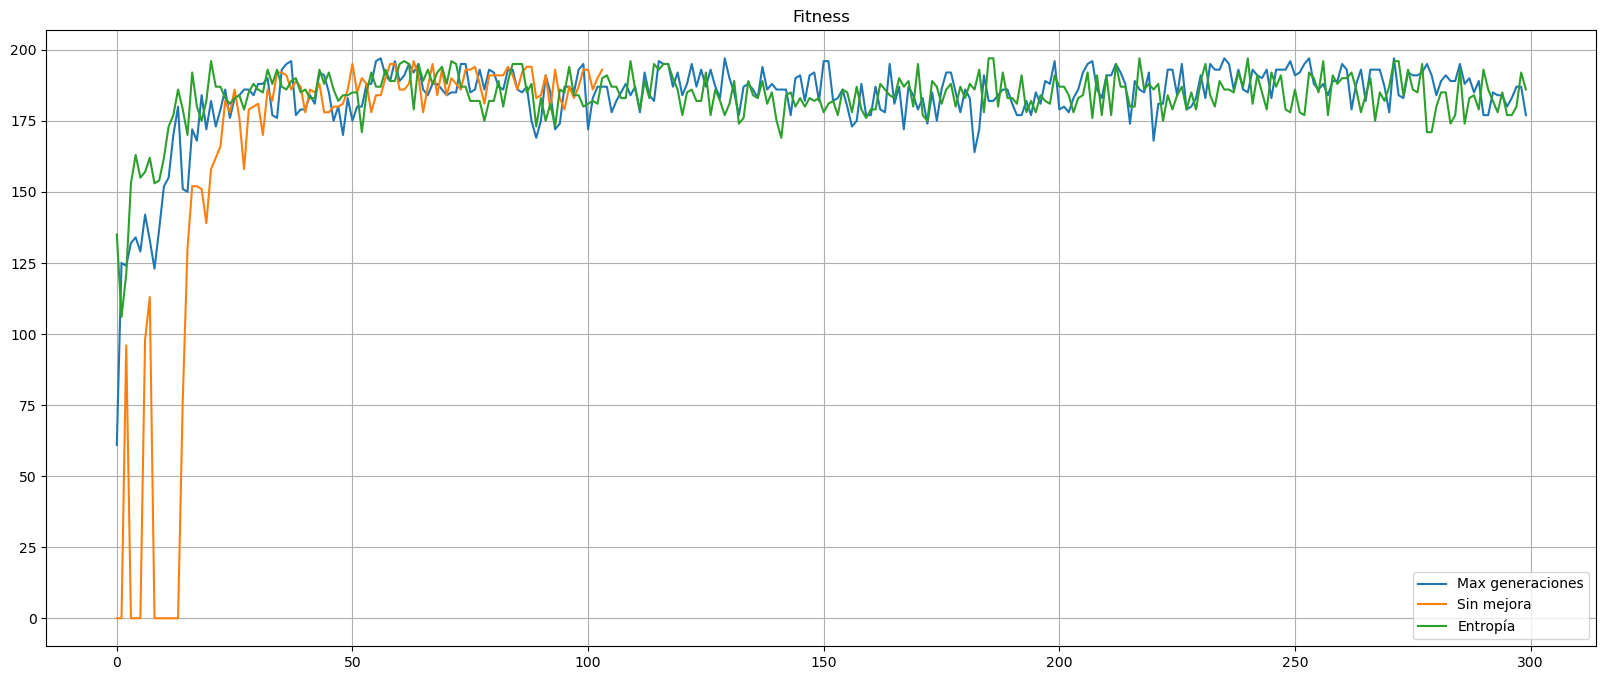

In [11]:
plt.figure(figsize=(20,8))
plt.plot(res_gen[0], label='Max generaciones')
plt.plot(res_est[0], label='Sin mejora')
plt.plot(res_ent[0], label='Entropía')
plt.legend(); plt.title('Fitness')
plt.grid(True)
plt.show()


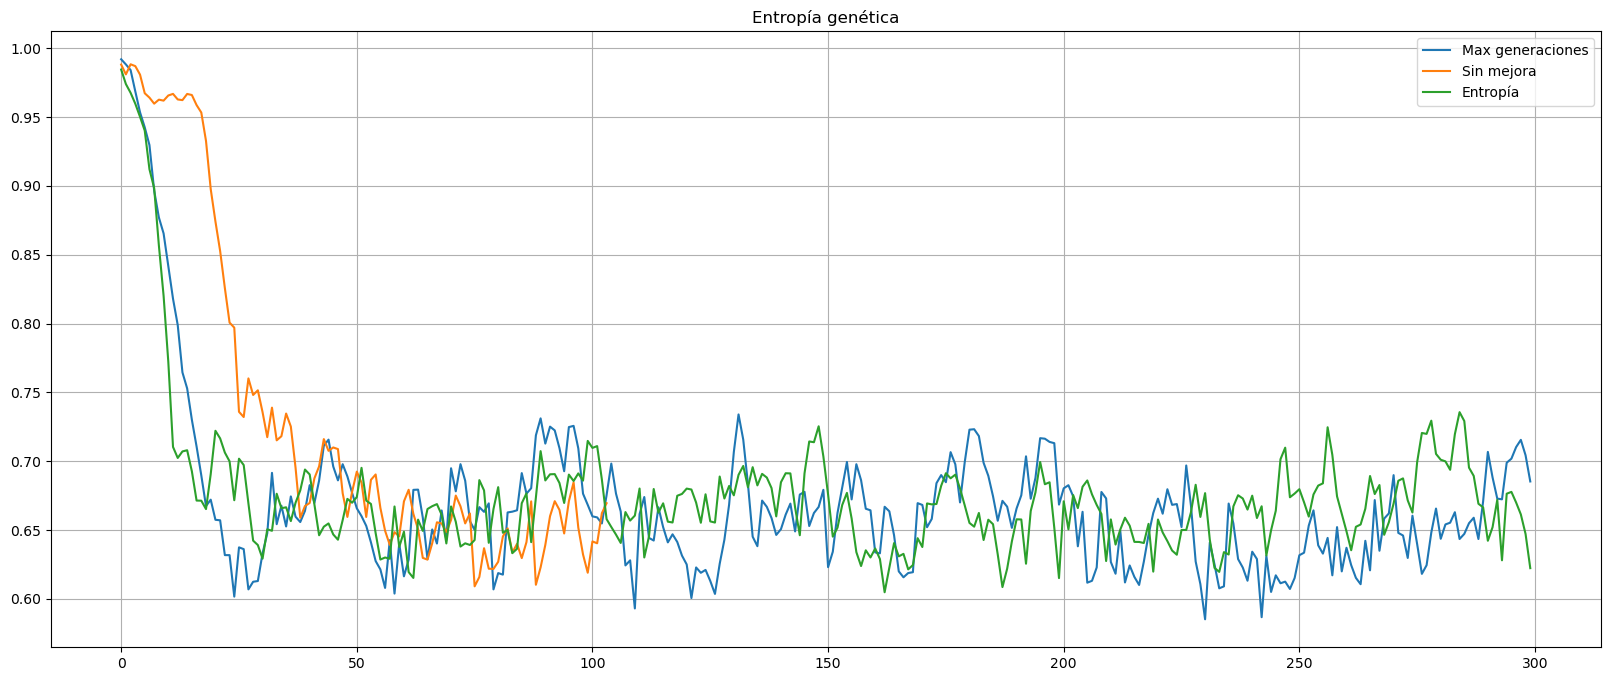

In [12]:
plt.figure(figsize=(20,8))
plt.plot(res_gen[1], label='Max generaciones')
plt.plot(res_est[1], label='Sin mejora')
plt.plot(res_ent[1], label='Entropía')
plt.legend(); plt.title('Entropía genética')
plt.grid(True)
plt.show()


## 7. Conclusiones

Esta comparación muestra que:
- distintos criterios detienen el algoritmo en momentos distintos
- no siempre el mayor número de generaciones produce mejores soluciones
- la entropía aporta información estructural independiente del fitness

El criterio de parada forma parte del diseño del algoritmo genético.